# Análise Exploratória — Campeonato Brasileiro de Futebol

**Projeto:** Predição de Resultados e Cartão Vermelho no Brasileirão  
**Disciplina:** Ciência de Dados Aplicada — FACAPE  
**Fonte:** `adaoduque/campeonato-brasileiro-de-futebol` via Kaggle  

**Target 1:** `resultado` — mandante / empate / visitante  
**Target 2:** `tem_cartao_vermelho` — 0 / 1  
**Anti-leakage:** features = médias rolantes das últimas 5 partidas de cada time **antes** do jogo.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

REPORTS = Path('../reports')
REPORTS.mkdir(exist_ok=True)

In [2]:
raw_files = sorted(Path('../data/raw').glob('brasileirao_*.parquet'))
if not raw_files:
    raise FileNotFoundError("Rode: python -m src.data_ingestion")

df = pd.read_parquet(raw_files[-1])
df['data'] = pd.to_datetime(df['data'], errors='coerce')
df['ano'] = df['data'].dt.year

print(f"Arquivo : {raw_files[-1].name}")
print(f"Shape   : {df.shape}  ({len(df)} partidas × {len(df.columns)} colunas)")
print(f"Período : {df['data'].min().date()} → {df['data'].max().date()}")
df.head(3)

Arquivo : brasileirao_20260506_1218.parquet
Shape   : (9138, 32)  (9138 partidas × 32 colunas)
Período : 2003-04-05 → 2025-12-07


,partida_id,rodata,data,mandante,visitante,mandante_Estado,visitante_Estado,resultado,tem_cartao_vermelho,mandante_chutes,...,visitante_posse_de_bola,visitante_passes,visitante_precisao_passes,visitante_faltas,visitante_cartao_amarelo,visitante_impedimentos,visitante_escanteios,visitante_gols_marcados,visitante_gols_sofridos,ano
0,15,2,2003-04-05,Coritiba,Internacional,PR,RS,visitante,0,0.0,...,NaN,0.0,NaN,0.0,0.0,0.0,0.0,1.0,1.0,2003
1,16,2,2003-04-05,Gremio,Guarani,RS,SP,mandante,0,0.0,...,NaN,0.0,NaN,0.0,0.0,0.0,0.0,4.0,2.0,2003
2,13,2,2003-04-05,Fluminense,Fortaleza,RJ,CE,empate,0,0.0,...,NaN,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,2003


## 1. Visão Geral

In [3]:
feat_cols = [c for c in df.select_dtypes(include='number').columns
             if c not in ('tem_cartao_vermelho', 'rodata')]
id_cols = ['partida_id', 'rodata', 'data', 'ano', 'mandante', 'visitante',
           'mandante_Estado', 'visitante_Estado', 'resultado', 'tem_cartao_vermelho']

print(f"Partidas            : {len(df)}")
print(f"Temporadas          : {df['ano'].nunique()} ({int(df['ano'].min())}–{int(df['ano'].max())})")
print(f"Times distintos     : {pd.concat([df['mandante'], df['visitante']]).nunique()}")
print(f"Features numéricas  : {len(feat_cols)}")
print(f"\nColunas: {df.columns.tolist()}")

Partidas            : 9138
Temporadas          : 23 (2003–2025)
Times distintos     : 46
Features numéricas  : 24

Colunas: ['partida_id', 'rodata', 'data', 'mandante', 'visitante', 'mandante_Estado', 'visitante_Estado', 'resultado', 'tem_cartao_vermelho', 'mandante_chutes', 'mandante_chutes_no_alvo', 'mandante_posse_de_bola', 'mandante_passes', 'mandante_precisao_passes', 'mandante_faltas', 'mandante_cartao_amarelo', 'mandante_impedimentos', 'mandante_escanteios', 'mandante_gols_marcados', 'mandante_gols_sofridos', 'visitante_chutes', 'visitante_chutes_no_alvo', 'visitante_posse_de_bola', 'visitante_passes', 'visitante_precisao_passes', 'visitante_faltas', 'visitante_cartao_amarelo', 'visitante_impedimentos', 'visitante_escanteios', 'visitante_gols_marcados', 'visitante_gols_sofridos', 'ano']


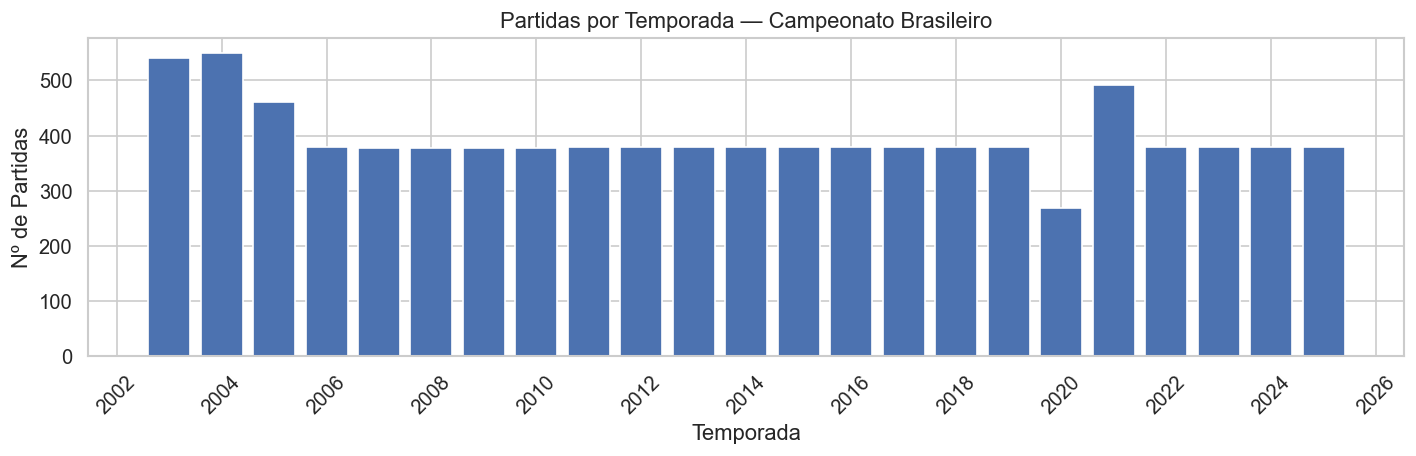

In [4]:
# Partidas por temporada
por_ano = df.groupby('ano').size().reset_index(name='n_partidas')

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(por_ano['ano'], por_ano['n_partidas'], color='#4C72B0', edgecolor='white')
ax.set_xlabel('Temporada')
ax.set_ylabel('Nº de Partidas')
ax.set_title('Partidas por Temporada — Campeonato Brasileiro')
ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(REPORTS / 'fig_partidas_por_ano.png', bbox_inches='tight')
plt.show()

## 2. Target 1 — Resultado da Partida

In [5]:
res_counts = df['resultado'].value_counts()
res_pct = df['resultado'].value_counts(normalize=True)

print("Distribuição do resultado:")
for r in ['mandante', 'empate', 'visitante']:
    print(f"  {r:12s}: {res_counts[r]:5d} partidas  ({res_pct[r]:.1%})")

Distribuição do resultado:
  mandante    :  4544 partidas  (49.7%)
  empate      :  2404 partidas  (26.3%)
  visitante   :  2190 partidas  (24.0%)


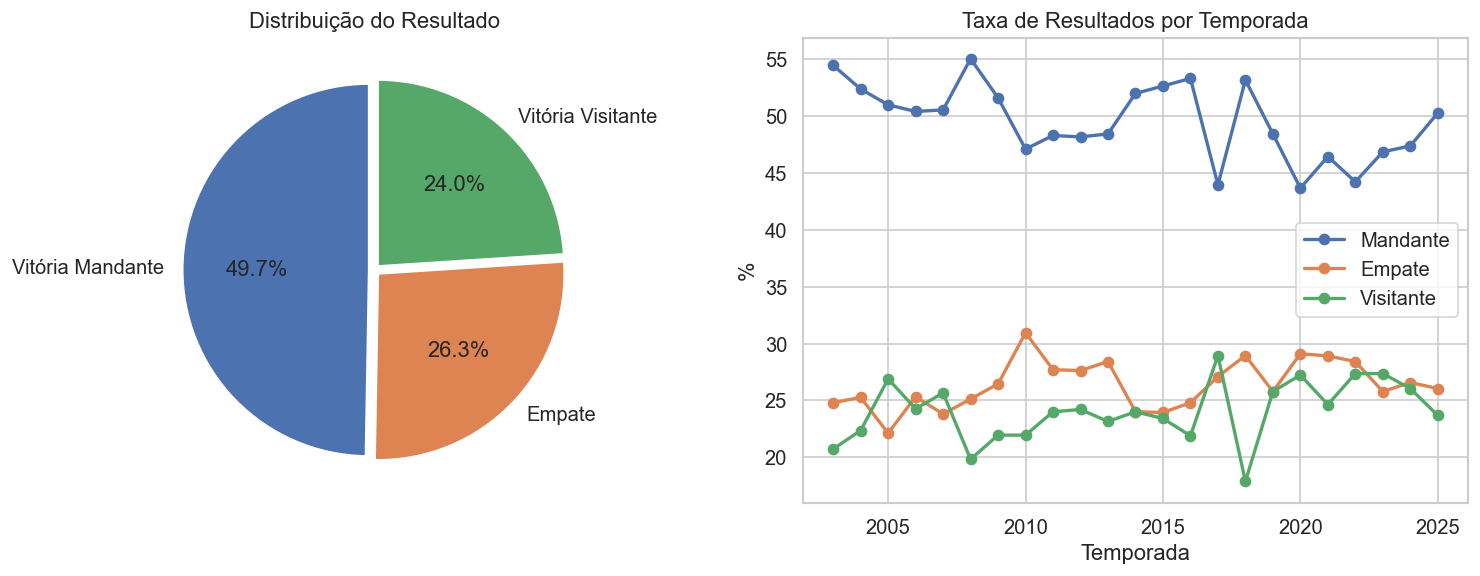

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pizza
cores = ['#4C72B0', '#DD8452', '#55A868']
axes[0].pie(
    [res_counts.get(r, 0) for r in ['mandante', 'empate', 'visitante']],
    labels=['Vitória Mandante', 'Empate', 'Vitória Visitante'],
    autopct='%1.1f%%', colors=cores, startangle=90, explode=[0.03]*3
)
axes[0].set_title('Distribuição do Resultado')

# Evolução temporal
res_ano = df.groupby(['ano', 'resultado']).size().unstack(fill_value=0)
res_ano_pct = res_ano.div(res_ano.sum(axis=1), axis=0) * 100
for r, cor in zip(['mandante', 'empate', 'visitante'], cores):
    if r in res_ano_pct.columns:
        axes[1].plot(res_ano_pct.index, res_ano_pct[r], marker='o', color=cor,
                     label=r.capitalize(), linewidth=2)
axes[1].set_xlabel('Temporada')
axes[1].set_ylabel('%')
axes[1].set_title('Taxa de Resultados por Temporada')
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORTS / 'fig_target_resultado.png', bbox_inches='tight')
plt.show()

## 3. Target 2 — Cartão Vermelho

In [7]:
n_cv = df['tem_cartao_vermelho'].sum()
pct_cv = df['tem_cartao_vermelho'].mean()
print(f"Partidas com cartão vermelho : {n_cv}  ({pct_cv:.1%})")
print(f"Desbalanceamento             : {(1-pct_cv)/pct_cv:.1f}:1  (sem:com)")

Partidas com cartão vermelho : 787  (8.6%)
Desbalanceamento             : 10.6:1  (sem:com)


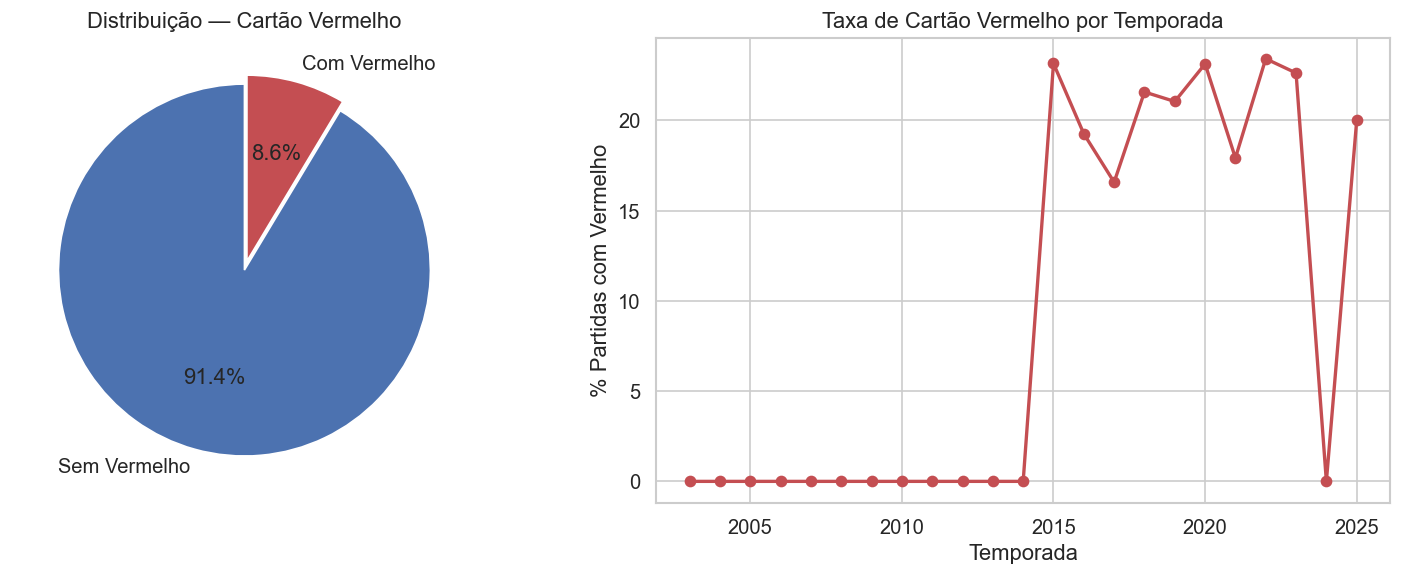

In [8]:
cv_ano = df.groupby('ano')['tem_cartao_vermelho'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie([1 - pct_cv, pct_cv], labels=['Sem Vermelho', 'Com Vermelho'],
            autopct='%1.1f%%', colors=['#4C72B0', '#C44E52'],
            startangle=90, explode=[0, 0.05])
axes[0].set_title('Distribuição — Cartão Vermelho')

axes[1].plot(cv_ano.index, cv_ano.values, marker='o', color='#C44E52', linewidth=2)
axes[1].set_xlabel('Temporada')
axes[1].set_ylabel('% Partidas com Vermelho')
axes[1].set_title('Taxa de Cartão Vermelho por Temporada')

plt.tight_layout()
plt.savefig(REPORTS / 'fig_target_cartao.png', bbox_inches='tight')
plt.show()

## 4. Distribuição das Features Rolantes

In [9]:
mand_feats = [c for c in feat_cols if c.startswith('mandante_')]
print(f"Features do mandante  : {len(mand_feats)}")
print(f"Nomes: {mand_feats}")
df[mand_feats].describe().round(2)

Features do mandante  : 11
Nomes: ['mandante_chutes', 'mandante_chutes_no_alvo', 'mandante_posse_de_bola', 'mandante_passes', 'mandante_precisao_passes', 'mandante_faltas', 'mandante_cartao_amarelo', 'mandante_impedimentos', 'mandante_escanteios', 'mandante_gols_marcados', 'mandante_gols_sofridos']


,mandante_chutes,mandante_chutes_no_alvo,mandante_posse_de_bola,mandante_passes,mandante_precisao_passes,mandante_faltas,mandante_cartao_amarelo,mandante_impedimentos,mandante_escanteios,mandante_gols_marcados,mandante_gols_sofridos
count,9138.00,9138.00,3888.00,9138.00,2682.00,9138.00,9138.00,9138.00,9138.00,9138.00,9138.00
mean,5.18,1.39,49.89,171.06,81.60,6.07,0.96,0.66,2.11,1.26,1.31
std,6.34,2.06,6.44,207.30,4.71,7.37,1.22,0.91,2.66,0.55,0.56
min,0.00,0.00,26.00,0.00,68.20,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,45.40,0.00,78.35,0.00,0.00,0.00,0.00,0.80,1.00
50%,0.00,0.00,49.80,0.00,81.40,0.00,0.00,0.00,0.00,1.20,1.20
75%,11.80,3.40,54.20,392.00,84.60,13.80,2.00,1.40,4.60,1.60,1.60
max,22.80,8.80,72.80,760.60,96.00,23.80,4.80,5.60,10.80,4.20,6.00


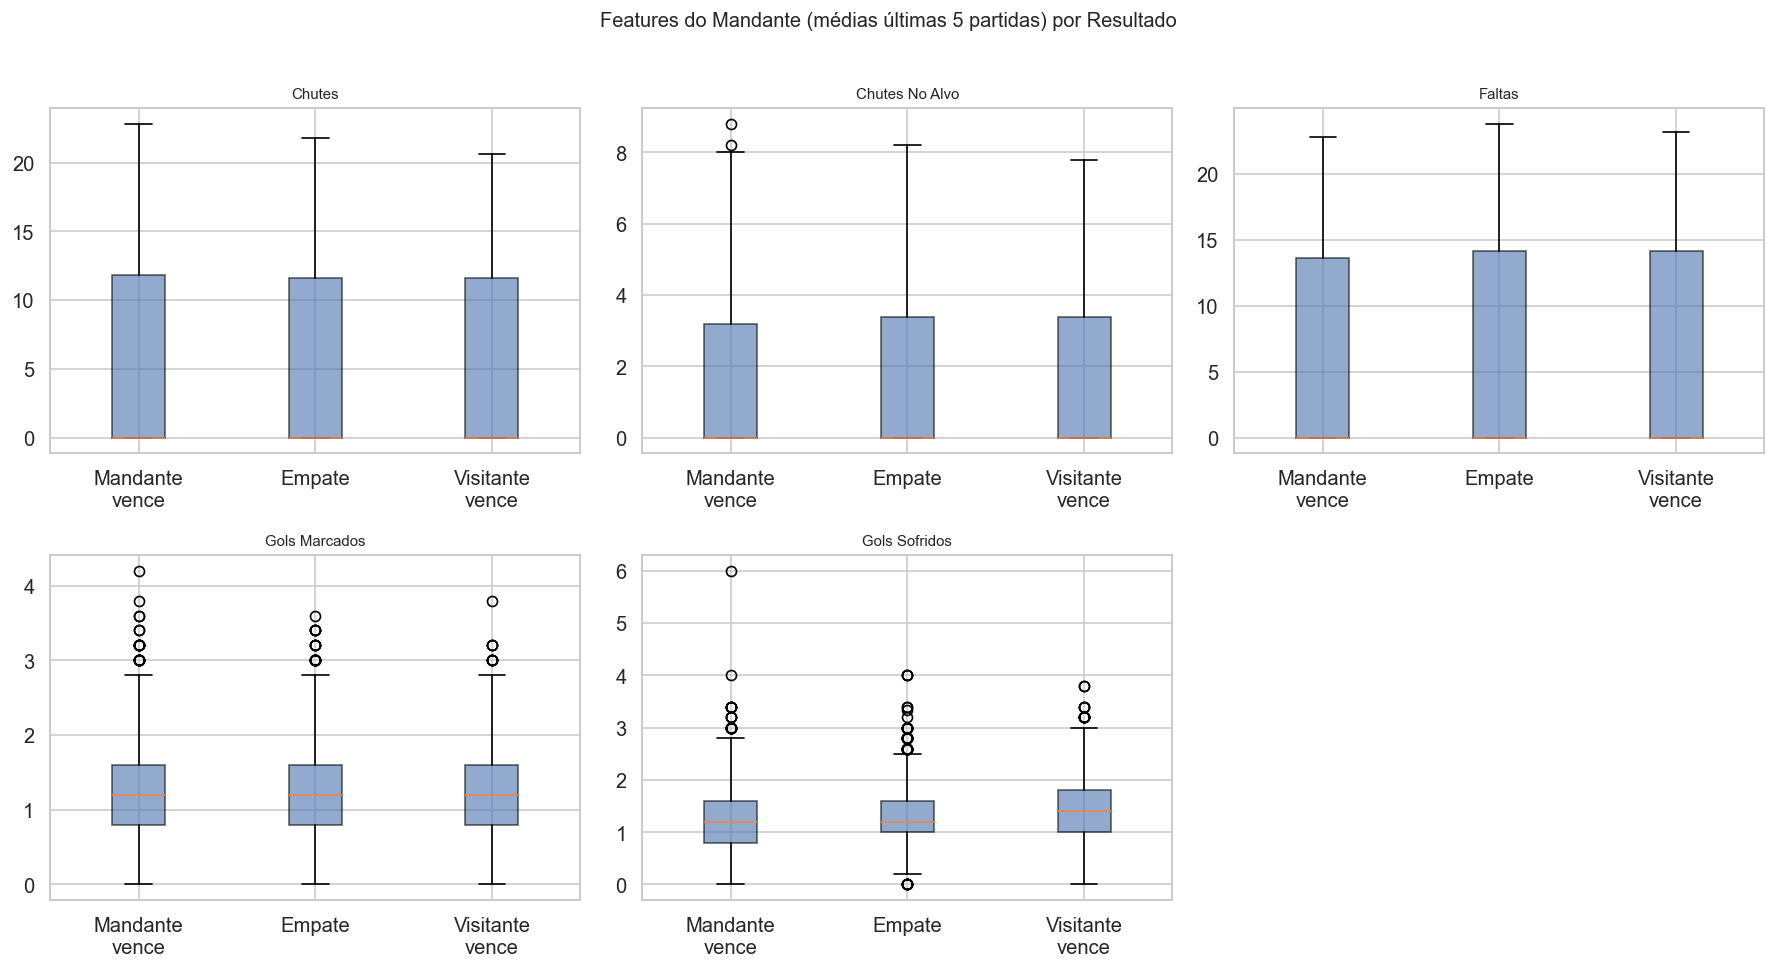

In [10]:
# Boxplot das features do mandante por resultado
plot_feats = [c for c in mand_feats if 'chutes' in c or 'gols' in c or 'faltas' in c]
n = len(plot_feats)
ncols = min(n, 3)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for i, col in enumerate(plot_feats):
    data = [df[df['resultado'] == r][col].dropna() for r in ['mandante', 'empate', 'visitante']]
    axes[i].boxplot(data, labels=['Mandante\nvence', 'Empate', 'Visitante\nvence'],
                    patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6))
    axes[i].set_title(col.replace('mandante_', '').replace('_', ' ').title(), fontsize=9)

for j in range(len(plot_feats), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Features do Mandante (médias últimas 5 partidas) por Resultado', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig(REPORTS / 'fig_boxplots_features.png', bbox_inches='tight')
plt.show()

## 5. Correlação entre Features

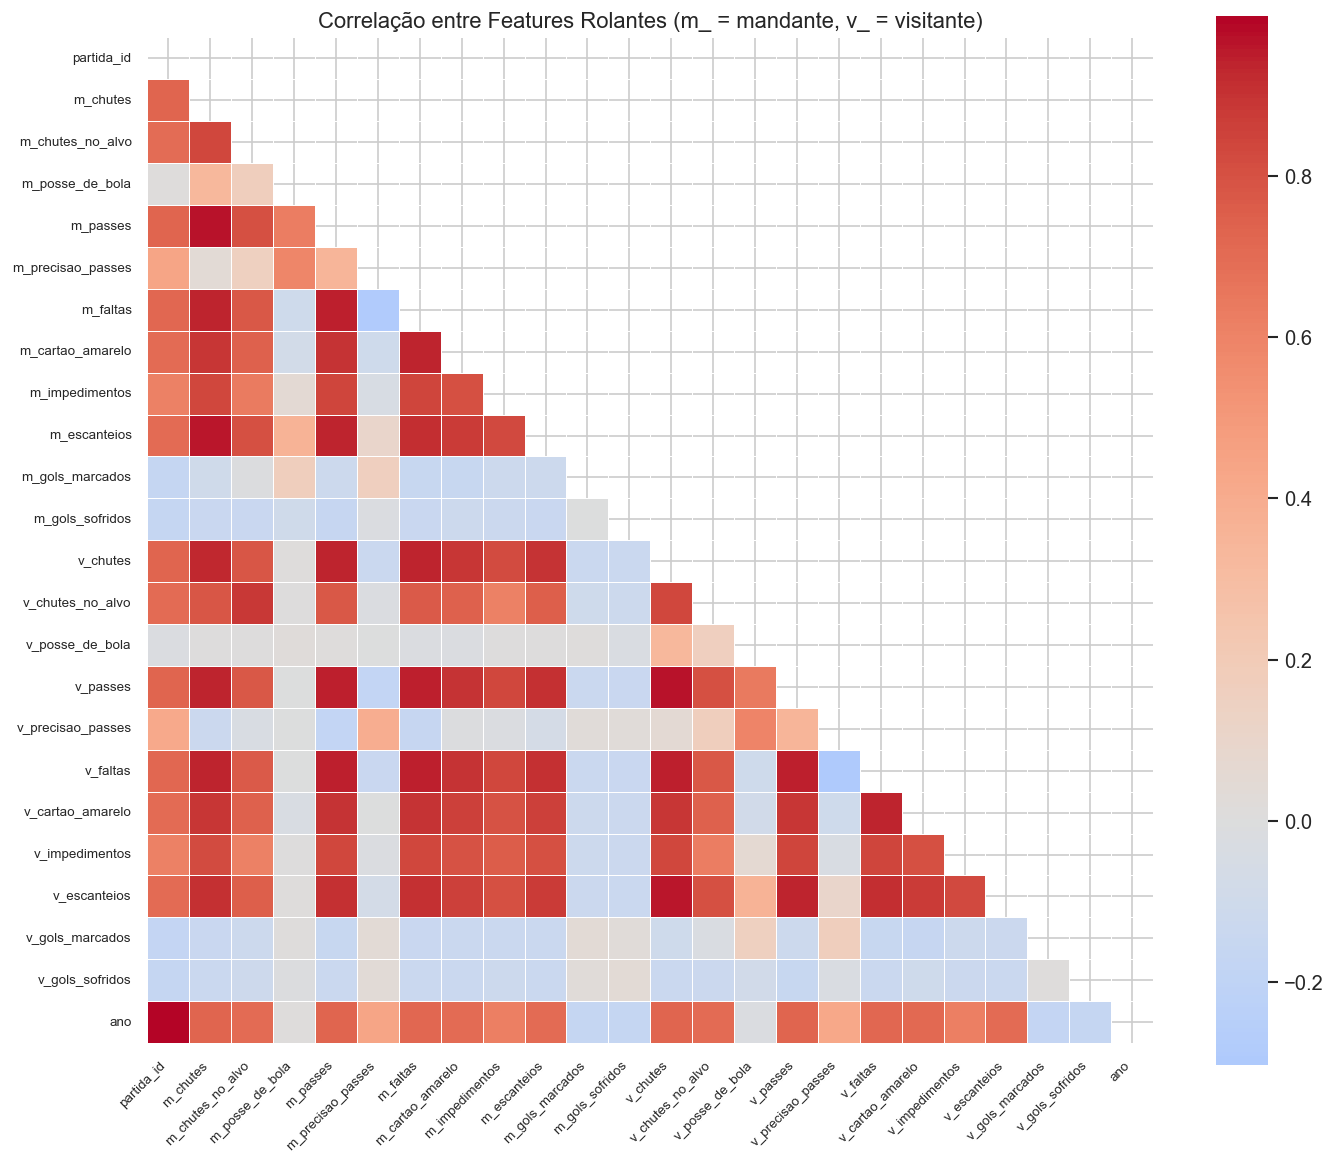

In [11]:
corr = df[feat_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, ax=ax, linewidths=0.3,
            xticklabels=[c.replace('mandante_', 'm_').replace('visitante_', 'v_') for c in feat_cols],
            yticklabels=[c.replace('mandante_', 'm_').replace('visitante_', 'v_') for c in feat_cols])
ax.set_title('Correlação entre Features Rolantes (m_ = mandante, v_ = visitante)')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(REPORTS / 'fig_correlacao.png', bbox_inches='tight')
plt.show()

## 6. Análise por Times — Aproveitamento como Mandante

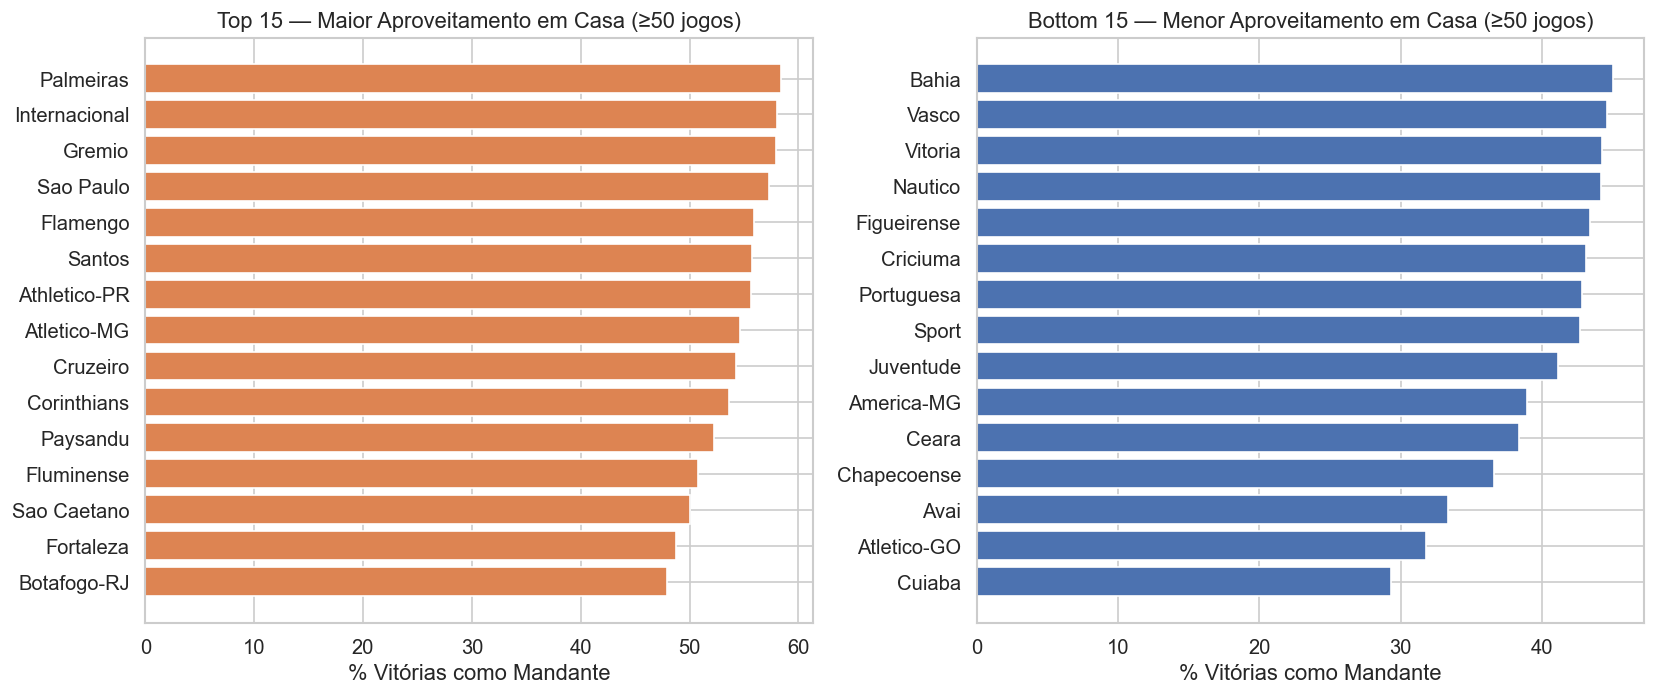

In [12]:
aproveitamento = (
    df.groupby('mandante')
    .apply(lambda g: pd.Series({
        'jogos': len(g),
        'vitorias': (g['resultado'] == 'mandante').sum(),
        'empates': (g['resultado'] == 'empate').sum(),
        'derrotas': (g['resultado'] == 'visitante').sum(),
    }))
    .reset_index()
)
aproveitamento['aproveitamento_pct'] = aproveitamento['vitorias'] / aproveitamento['jogos'] * 100
aproveitamento = aproveitamento[aproveitamento['jogos'] >= 50].sort_values('aproveitamento_pct', ascending=False)

top15 = aproveitamento.head(15)
bot15 = aproveitamento.tail(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top15['mandante'][::-1], top15['aproveitamento_pct'][::-1], color='#DD8452')
axes[0].set_title('Top 15 — Maior Aproveitamento em Casa (≥50 jogos)')
axes[0].set_xlabel('% Vitórias como Mandante')

axes[1].barh(bot15['mandante'][::-1], bot15['aproveitamento_pct'][::-1], color='#4C72B0')
axes[1].set_title('Bottom 15 — Menor Aproveitamento em Casa (≥50 jogos)')
axes[1].set_xlabel('% Vitórias como Mandante')

plt.tight_layout()
plt.savefig(REPORTS / 'fig_aproveitamento_times.png', bbox_inches='tight')
plt.show()

## 7. Resumo para o Artigo

In [13]:
print('=' * 60)
print('RESUMO — SEÇÃO DADOS DO ARTIGO')
print('=' * 60)
print(f'Fonte              : Campeonato Brasileiro (Kaggle)')
print(f'Período            : {int(df["ano"].min())} – {int(df["ano"].max())}')
print(f'Partidas totais    : {len(df)}')
print(f'Times distintos    : {pd.concat([df["mandante"], df["visitante"]]).nunique()}')
print(f'Features rolantes  : {len(feat_cols)}')
print()
print('Target 1 — Resultado:')
for r in ['mandante', 'empate', 'visitante']:
    print(f'  {r:12s}: {res_counts.get(r, 0):5d}  ({res_pct.get(r, 0):.1%})')
print()
print(f'Target 2 — Cartão vermelho:')
print(f'  Com vermelho   : {n_cv:5d}  ({pct_cv:.1%})')
print(f'  Sem vermelho   : {len(df)-n_cv:5d}  ({1-pct_cv:.1%})')
print(f'  Desbalanceamento: {(1-pct_cv)/pct_cv:.1f}:1')
print('=' * 60)

RESUMO — SEÇÃO DADOS DO ARTIGO
Fonte              : Campeonato Brasileiro (Kaggle)
Período            : 2003 – 2025
Partidas totais    : 9138
Times distintos    : 46
Features rolantes  : 24

Target 1 — Resultado:
  mandante    :  4544  (49.7%)
  empate      :  2404  (26.3%)
  visitante   :  2190  (24.0%)

Target 2 — Cartão vermelho:
  Com vermelho   :   787  (8.6%)
  Sem vermelho   :  8351  (91.4%)
  Desbalanceamento: 10.6:1


In [ ]:
Grid search